# Laboratório 6 – Limiarização de Imagens

**Disciplina:** Processamento Digital de Imagens  

## Autores:
- Igor Ladeia de Freitas (RA11201922180)
- Gustavo Fernandes do Nascimento (RA11202021700)
- Ryan Lucas da Silva (RA11202522362)
- Eduardo Yukio Makita (RA11202020221)

**Data de realização:** 02/04/2026  
**Data de publicação:** 03/04/2026

## Introdução

Neste laboratório são estudadas técnicas de limiarização de imagens, com foco na segmentação binária de objetos em relação ao fundo. O objetivo é comparar a limiarização manual com a limiarização automática por Otsu, analisando seu comportamento em diferentes imagens.

Os experimentos foram realizados com imagens próprias do grupo, incluindo as imagens obtidas no Lab3, os avatares dos integrantes e imagens relacionadas ao projeto final. Também foi utilizado um exemplo clássico de segmentação, a imagem `rice.png`, além de um experimento em tempo real com webcam.

## Procedimentos experimentais

As imagens utilizadas neste trabalho foram armazenadas no GitHub da equipe e acessadas no notebook do Google Colab. Para os experimentos, foram utilizadas as bibliotecas NumPy, OpenCV e Matplotlib. Também foi baixado o arquivo `morph.py`, solicitado no roteiro do laboratório.

Os testes incluíram:
- limiarização manual com diferentes valores de limiar;
- limiarização automática pelo método de Otsu;
- processamento em tempo real com webcam;
- aplicação da técnica nas imagens do projeto final;
- análise dos resultados visuais e dos artefatos obtidos.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen


In [3]:
# Baixar o arquivo morph.py, exigido no laboratório
!wget -q https://raw.githubusercontent.com/fzampirolli/morph/main/morph.py

In [4]:
import morph

ModuleNotFoundError: No module named 'skimage'

## Funções auxiliares

Nesta etapa serão criadas funções para:
- carregar imagens do GitHub;
- converter para tons de cinza;
- aplicar limiarização manual;
- aplicar limiarização de Otsu;
- exibir os resultados lado a lado.

In [5]:
def load_image_from_url(url, color=cv2.IMREAD_COLOR):
    resp = urlopen(url)
    arr = np.asarray(bytearray(resp.read()), dtype=np.uint8)
    img = cv2.imdecode(arr, color)
    return img

def show_image(img, title="", cmap=None):
    plt.figure(figsize=(6, 4))
    if len(img.shape) == 2:
        plt.imshow(img, cmap=cmap or 'gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

def threshold_manual(gray_img, T):
    _, binary = cv2.threshold(gray_img, T, 255, cv2.THRESH_BINARY)
    return binary

def threshold_otsu(gray_img):
    T, binary = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return T, binary

def show_side_by_side(original, binary, titles=("Original", "Binária")):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    if len(original.shape) == 2:
        plt.imshow(original, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title(titles[0])
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(binary, cmap='gray')
    plt.title(titles[1])
    plt.axis('off')

    plt.tight_layout()
    plt.show()

## Carregamento das imagens do trabalho

Nesta seção serão carregadas as imagens do grupo, dos avatares e da imagem do projeto final.  
No GitHub, os arquivos devem ser acessados pelo link `raw`, e não pelo link comum de visualização.

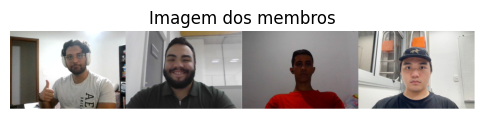

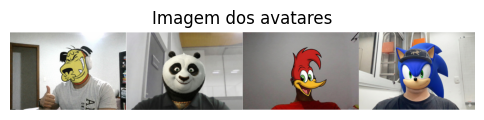

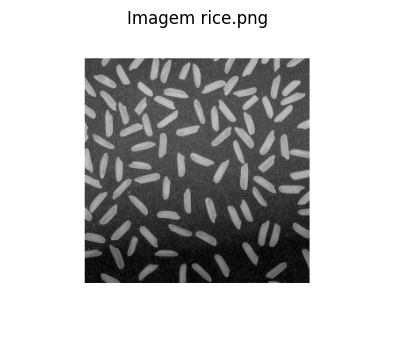

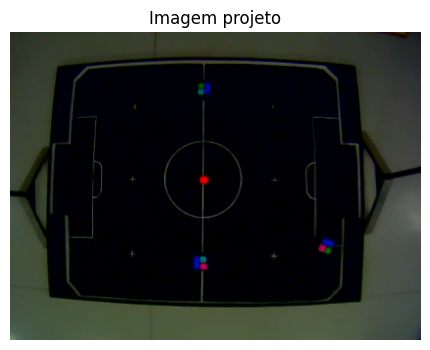

In [12]:
# Links RAW do GitHub (convertidos automaticamente)

url_membros = "https://raw.githubusercontent.com/IgorLadeia/Processamento_Digital_Imagens/main/imagens/Lab2/imagem_grupo.png"
url_avatares = "https://raw.githubusercontent.com/IgorLadeia/Processamento_Digital_Imagens/main/imagens/Lab2/imagem_grupo_avatar.png"
url_rice = "https://raw.githubusercontent.com/IgorLadeia/Processamento_Digital_Imagens/main/imagens/rice.png"
url_proj = "https://raw.githubusercontent.com/IgorLadeia/Processamento_Digital_Imagens/main/imagens/frame_02820.png"

# Carregamento das imagens
img_membros = load_image_from_url(url_membros)
img_avatares = load_image_from_url(url_avatares)
img_rice = load_image_from_url(url_rice, cv2.IMREAD_GRAYSCALE)
img_proj = load_image_from_url(url_proj)

# Exibição
show_image(img_membros, "Imagem dos membros")
show_image(img_avatares, "Imagem dos avatares")
show_image(img_rice, "Imagem rice.png")
show_image(img_proj, "Imagem projeto")

## 3.a) Limiarização Manual e Método de Otsu

Nesta etapa foram aplicadas técnicas de limiarização manual e automática (método de Otsu) nas imagens dos integrantes do grupo e em seus respectivos avatares.

A limiarização manual consiste na escolha de um valor de limiar T definido pelo usuário. Já o método de Otsu calcula automaticamente um valor ótimo de limiar com base na distribuição dos níveis de cinza da imagem.

Foram testados diferentes valores de limiar manual para analisar seu impacto no resultado final e comparar com o desempenho do método automático.

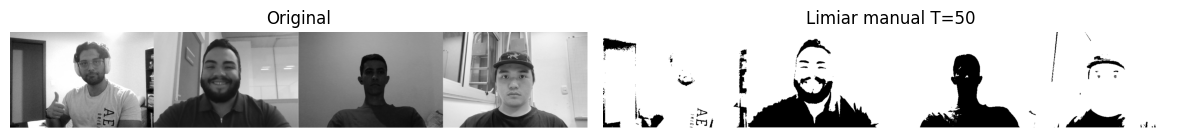

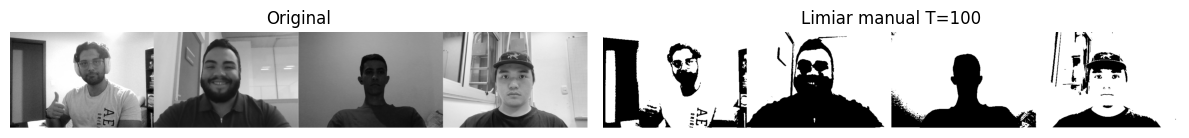

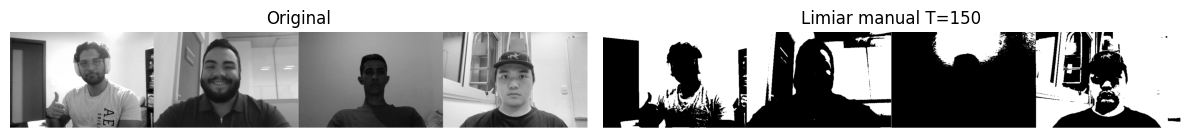

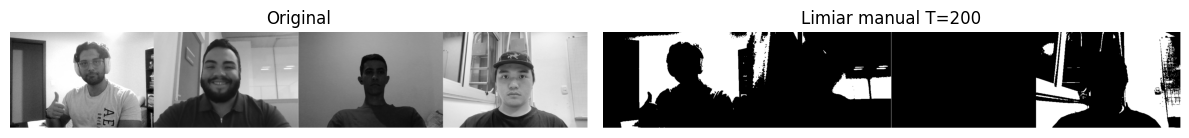

In [7]:
# Testando diferentes limiares na imagem dos membros

gray_membros = cv2.cvtColor(img_membros, cv2.COLOR_BGR2GRAY)

thresholds = [50, 100, 150, 200]

for T in thresholds:
    binary = threshold_manual(gray_membros, T)
    show_side_by_side(gray_membros, binary,
                      titles=("Original", f"Limiar manual T={T}"))

Limiar encontrado por Otsu: 135.0


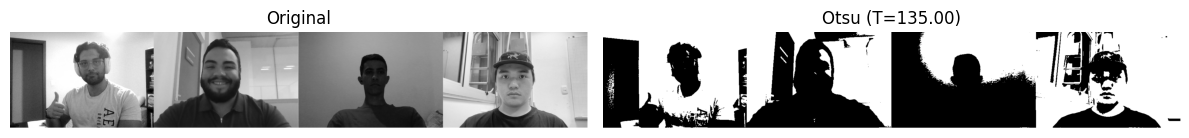

In [8]:
# Aplicando Otsu na imagem dos membros

T_otsu, binary_otsu = threshold_otsu(gray_membros)

print(f"Limiar encontrado por Otsu: {T_otsu}")

show_side_by_side(gray_membros, binary_otsu,
                  titles=("Original", f"Otsu (T={T_otsu:.2f})"))

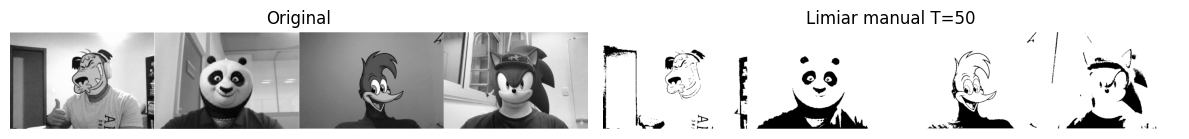

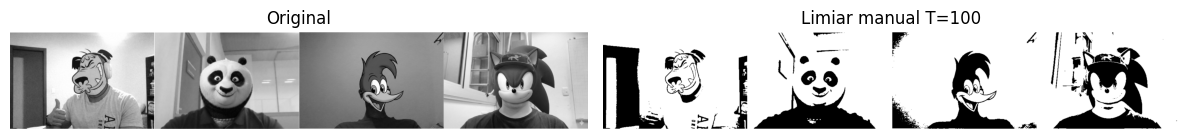

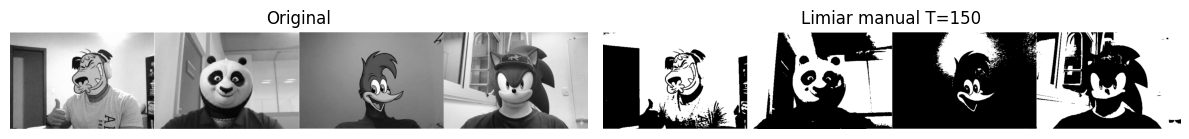

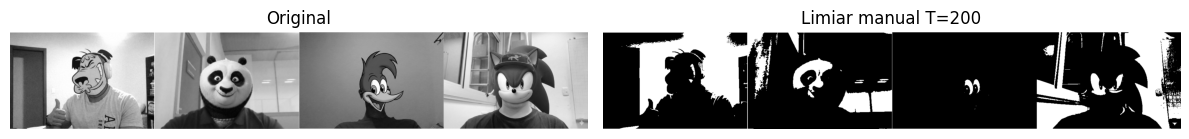

In [9]:
# Testando limiares na imagem dos avatares
gray_avatares = cv2.cvtColor(img_avatares, cv2.COLOR_BGR2GRAY)

for T in thresholds:
    binary = threshold_manual(gray_avatares, T)
    show_side_by_side(gray_avatares, binary,
                      titles=("Original", f"Limiar manual T={T}"))

Limiar encontrado por Otsu (avatares): 139.0


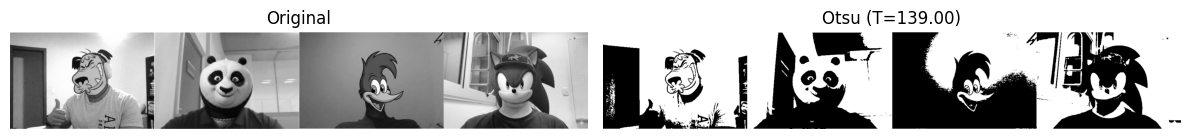

In [10]:
# Aplicando Otsu na imagem dos avatares

T_otsu_avatar, binary_otsu_avatar = threshold_otsu(gray_avatares)

print(f"Limiar encontrado por Otsu (avatares): {T_otsu_avatar}")

show_side_by_side(gray_avatares, binary_otsu_avatar,
                  titles=("Original", f"Otsu (T={T_otsu_avatar:.2f})"))

## Análise dos Resultados

A escolha do valor de limiar T influencia diretamente a qualidade da segmentação da imagem.

Para valores baixos de limiar (ex: T=50), grande parte da imagem é considerada como objeto, resultando em uma imagem binária com excesso de regiões brancas, incluindo áreas do fundo.

Para valores altos (ex: T=200), ocorre o efeito oposto, onde apenas regiões muito claras são mantidas, podendo causar perda de detalhes importantes do objeto.

Observa-se que não existe um único valor de limiar manual que funcione perfeitamente para todas as imagens, pois a escolha depende da iluminação, contraste e distribuição dos níveis de cinza.

O método de Otsu, por sua vez, determina automaticamente um valor de limiar baseado no histograma da imagem, buscando maximizar a separação entre fundo e objeto. Nos testes realizados, o método apresentou resultados mais equilibrados, com melhor definição das regiões de interesse, especialmente nas imagens com boa separação de intensidades.

Entretanto, em imagens com iluminação irregular ou baixo contraste, o método de Otsu pode não apresentar resultados ideais, pois assume uma distribuição bimodal dos níveis de cinza.

## 3.b) Limiarização em tempo real com webcam

Nesta etapa foi desenvolvido um programa capaz de capturar imagens em tempo real utilizando a webcam, aplicando técnicas de limiarização e exibindo os resultados lado a lado com a imagem original.

O sistema permite ao usuário alternar entre limiarização manual e automática (método de Otsu) por meio do teclado. Também é possível ajustar dinamicamente o valor do limiar manual.

Essa abordagem permite observar, em tempo real, o impacto das diferentes técnicas de segmentação, bem como identificar possíveis artefatos causados por iluminação, ruído e variações no cenário.

In [11]:
import cv2

cap = cv2.VideoCapture(0)

modo = "manual"   # "manual" ou "otsu"
T = 100           # limiar inicial

print("Controles:")
print("m - modo manual")
print("o - modo Otsu")
print("+ - aumentar limiar")
print("- - diminuir limiar")
print("q - sair")

while True:
    ret, frame = cap.read()
    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    if modo == "manual":
        _, binary = cv2.threshold(gray, T, 255, cv2.THRESH_BINARY)
        texto = f"Manual T={T}"
    else:
        T_otsu, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        texto = f"Otsu T={int(T_otsu)}"

    # Converter para BGR para poder concatenar
    binary_bgr = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)

    resultado = cv2.hconcat([frame, binary_bgr])

    cv2.putText(resultado, texto, (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    cv2.imshow("Limiarizacao em tempo real", resultado)

    key = cv2.waitKey(1) & 0xFF

    if key == ord('q'):
        break
    elif key == ord('m'):
        modo = "manual"
    elif key == ord('o'):
        modo = "otsu"
    elif key == ord('+'):
        T = min(255, T + 5)
    elif key == ord('-'):
        T = max(0, T - 5)

cap.release()
cv2.destroyAllWindows()

Controles:
m - modo manual
o - modo Otsu
+ - aumentar limiar
- - diminuir limiar
q - sair


QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/PDI26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/PDI26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/PDI26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/ufabc/miniconda3/envs/PDI26/lib/python3.14/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find f

## Análise dos Resultados (Webcam)

Durante a execução do programa em tempo real, foi possível observar que a limiarização manual depende fortemente do valor escolhido para o limiar T. Pequenas variações nesse valor podem causar mudanças significativas na segmentação da imagem.

Em ambientes com iluminação variável, o método manual apresenta dificuldades, exigindo constantes ajustes por parte do usuário.

O método de Otsu, por outro lado, adapta automaticamente o limiar conforme as condições da imagem, proporcionando maior robustez em situações com variações de iluminação.

Entretanto, foram observados alguns artefatos, como:
- ruídos na imagem binária;
- perda de detalhes em regiões com baixo contraste;
- segmentação incorreta em cenários com iluminação não uniforme.

Esses efeitos ocorrem devido à presença de sombras, reflexos e variações na intensidade dos pixels, que dificultam a separação clara entre objeto e fundo.

## 4.a) Aplicação da Limiarização no Projeto Final

Neste experimento, as técnicas de limiarização foram aplicadas às imagens do projeto final da equipe, cujo objetivo é identificar a posição e o ângulo de um robô em um campo, utilizando marcadores visuais baseados em formas geométricas coloridas.

A limiarização é utilizada como etapa de pré-processamento, permitindo separar regiões de interesse (marcadores no robô) do fundo da imagem. Isso facilita etapas posteriores, como detecção de contornos, identificação de formas e cálculo de posição e orientação.

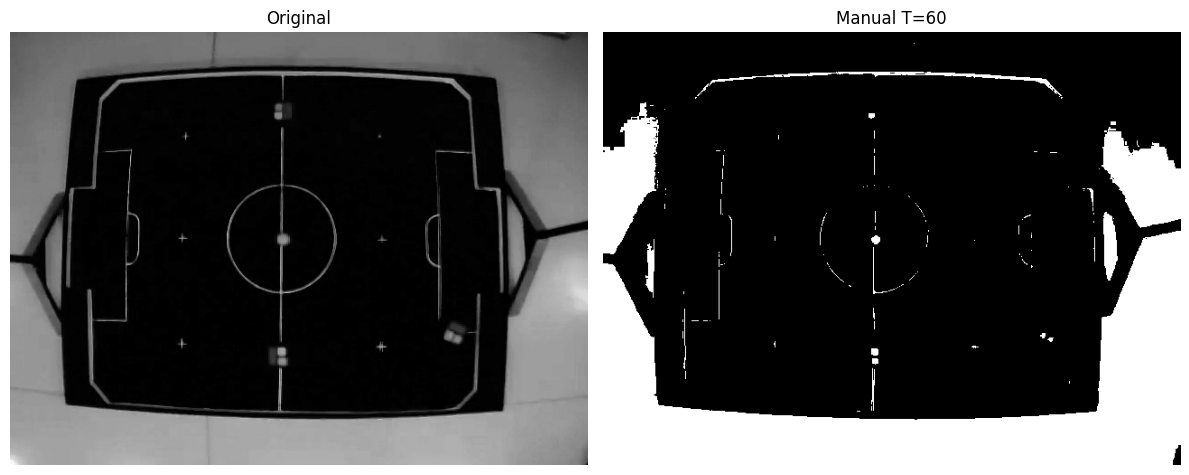

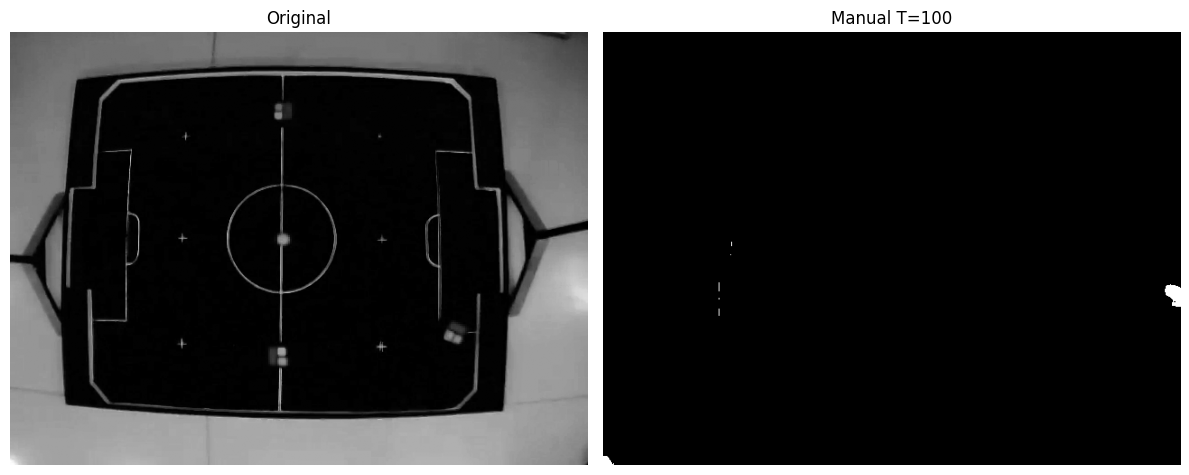

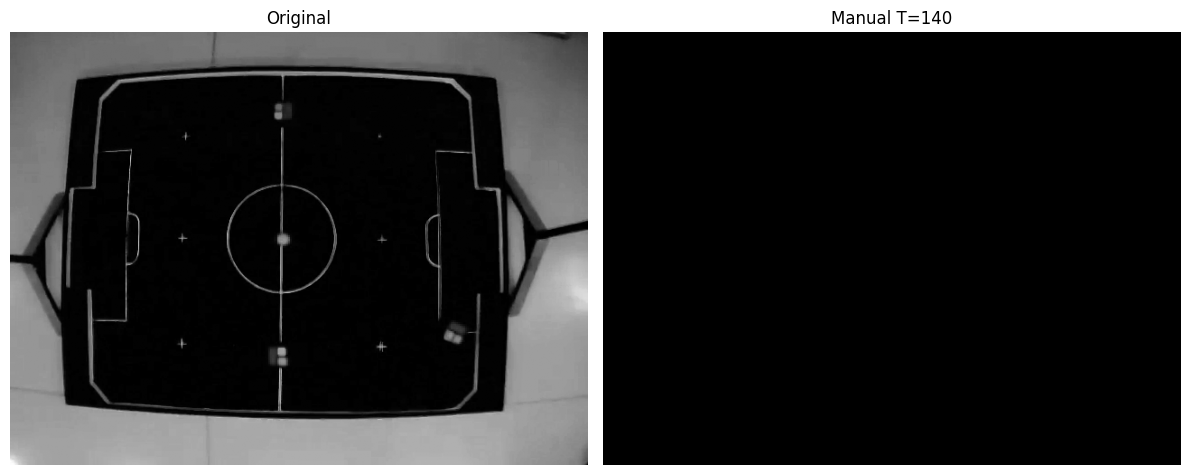

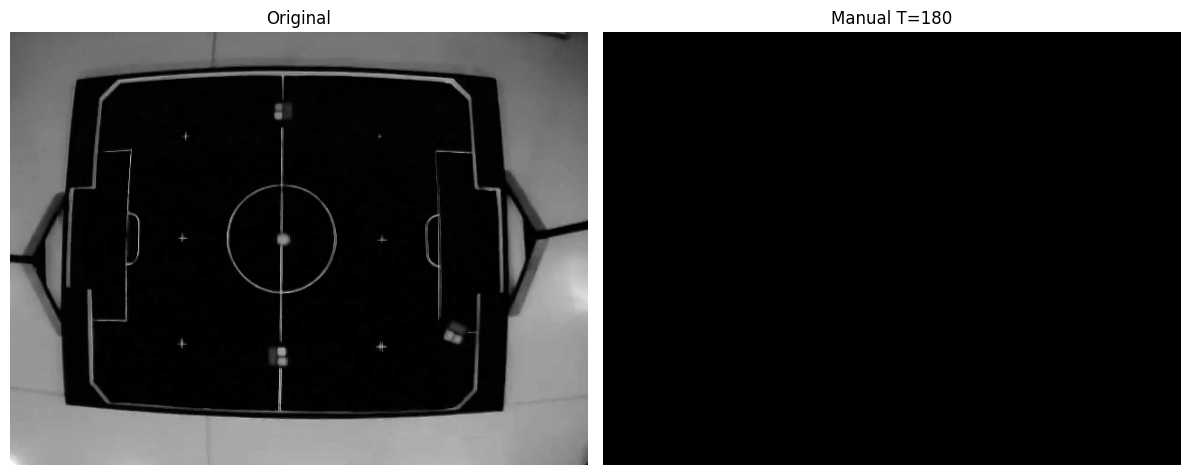

In [13]:
# Teste com diferentes limiares
gray_projeto = cv2.cvtColor(img_proj, cv2.COLOR_BGR2GRAY)

thresholds = [60, 100, 140, 180]

for T in thresholds:
    binary = threshold_manual(gray_projeto, T)
    show_side_by_side(gray_projeto, binary, 
                      titles=("Original", f"Manual T={T}"))

Limiar de Otsu (projeto): 34.0


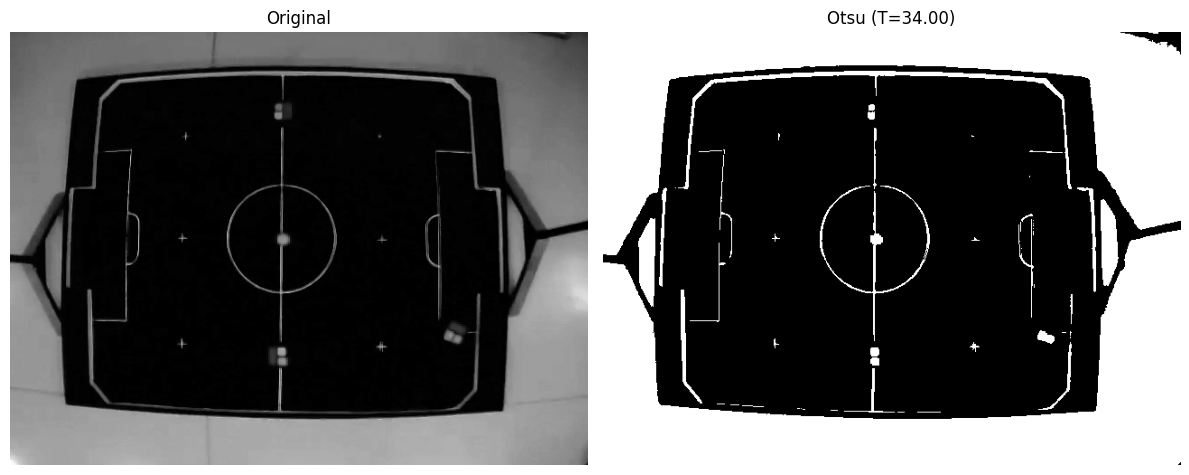

In [14]:
T_otsu_proj, binary_otsu_proj = threshold_otsu(gray_projeto)

print(f"Limiar de Otsu (projeto): {T_otsu_proj}")

show_side_by_side(gray_projeto, binary_otsu_proj, 
                  titles=("Original", f"Otsu (T={T_otsu_proj:.2f})"))

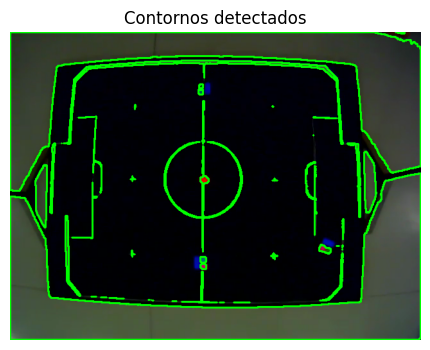

In [16]:
# Detectar contornos na imagem binária (Otsu)

contours, _ = cv2.findContours(binary_otsu_proj, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

img_contours = img_proj.copy()

cv2.drawContours(img_contours, contours, -1, (0,255,0), 2)

show_image(img_contours, "Contornos detectados")

## Análise dos Resultados

A aplicação da limiarização no contexto do projeto final mostrou-se fundamental para a segmentação das regiões de interesse, correspondentes aos marcadores visuais presentes no robô.

A limiarização manual permitiu observar que a escolha do limiar influencia diretamente a qualidade da segmentação. Valores inadequados podem resultar em perda de partes dos marcadores ou inclusão de ruídos do fundo.

O método de Otsu apresentou melhor desempenho geral, ajustando automaticamente o limiar conforme a distribuição de intensidades da imagem, resultando em uma segmentação mais consistente.

A partir da imagem binarizada, foi possível realizar a detecção de contornos, etapa essencial para identificar as formas geométricas utilizadas como marcadores. Esses contornos podem ser utilizados para determinar a posição e orientação do robô no ambiente.

Dessa forma, a limiarização atua como uma etapa chave no pipeline do sistema de visão computacional, simplificando a imagem e facilitando a extração de características relevantes.

## 5.a) Diferença entre inspeção visual e métodos automáticos

Na limiarização de imagens, a escolha do valor de limiar T pode ser realizada por meio de inspeção visual do histograma ou por métodos automáticos, como o método de Otsu.

A inspeção visual consiste em analisar o histograma da imagem e escolher manualmente um valor de limiar que melhor separe as regiões de interesse do fundo. Essa abordagem depende da interpretação do usuário, sendo considerada subjetiva. Sua principal vantagem é a flexibilidade, permitindo ajustes finos para casos específicos. No entanto, sua principal desvantagem é a falta de reprodutibilidade e a dificuldade de aplicação em grandes volumes de imagens.

Por outro lado, os métodos automáticos determinam o limiar de forma matemática, sem intervenção humana. O método de Otsu, por exemplo, seleciona o valor de limiar que minimiza a variância intra-classe ou maximiza a separação entre fundo e objeto. Essa abordagem é objetiva, reprodutível e eficiente para processamento em larga escala.

Como desvantagem, métodos automáticos podem apresentar desempenho inferior em imagens com baixa separação entre classes, iluminação irregular ou histogramas não bimodais, onde a distinção entre objeto e fundo não é clara.

Em resumo, a escolha entre os métodos depende do contexto da aplicação, sendo a inspeção visual mais adequada para ajustes finos e os métodos automáticos mais indicados para sistemas automatizados.

## 5.b) Impacto da escolha do limiar

A escolha do valor de limiar T tem impacto direto na qualidade da segmentação da imagem.

Um limiar muito baixo, como T=50, faz com que muitos pixels sejam classificados como pertencentes ao objeto, incluindo regiões do fundo. Isso resulta em uma imagem binária com excesso de áreas brancas e baixa distinção entre objeto e fundo.

Por outro lado, um limiar muito alto, como T=125, pode eliminar partes importantes do objeto, mantendo apenas regiões muito claras. Isso causa perda de informação relevante e uma segmentação incompleta.

Com base no histograma da imagem “img2”, o valor ideal de limiar deve estar localizado na região entre os dois picos (quando presentes), representando a separação entre fundo e objeto. Esse ponto geralmente corresponde a um vale no histograma.

Um valor de limiar intermediário tende a produzir melhores resultados, pois equilibra a preservação das características do objeto e a remoção do fundo. A escolha adequada depende da distribuição dos níveis de cinza e da separação entre as classes presentes na imagem.

## 5.c) Vantagens do método de Otsu na imagem rice.png

Na segmentação da imagem “rice.png”, o método de Otsu apresenta como principal vantagem a capacidade de determinar automaticamente o valor de limiar ideal, sem a necessidade de tentativa e erro.

Essa característica é especialmente importante em imagens contendo múltiplos objetos, como os grãos de arroz, onde a escolha manual do limiar pode ser difícil e inconsistente. O método de Otsu analisa o histograma da imagem e seleciona um limiar que melhor separa os grãos do fundo, proporcionando uma segmentação mais uniforme.

Além disso, o uso de um método automático garante maior reprodutibilidade dos resultados, sendo fundamental em aplicações que exigem processamento de grandes quantidades de imagens.

Comparado ao método manual, o Otsu reduz o tempo de ajuste e minimiza a subjetividade, tornando o processo mais eficiente e confiável para esse tipo de aplicação.

## Conclusão

Neste laboratório foi possível compreender e aplicar técnicas de limiarização de imagens, explorando tanto abordagens manuais quanto automáticas, com destaque para o método de Otsu.

Através dos experimentos realizados, observou-se que a limiarização manual oferece maior controle sobre o processo de segmentação, porém depende fortemente da escolha adequada do valor de limiar, sendo sensível a variações de iluminação e contraste. Já o método de Otsu demonstrou maior robustez, por selecionar automaticamente um limiar com base na distribuição dos níveis de cinza da imagem, proporcionando resultados mais consistentes na maioria dos casos.

Os testes com imagens reais e com a webcam evidenciaram desafios práticos, como ruídos, sombras e iluminação não uniforme, que impactam diretamente na qualidade da segmentação. Esses fatores reforçam a importância da escolha adequada da técnica de limiarização conforme o contexto da aplicação.

Além disso, a aplicação das técnicas no projeto final mostrou que a limiarização é uma etapa essencial no pipeline de visão computacional, facilitando a detecção de objetos, contornos e características relevantes para a identificação da posição e orientação do robô.

Dessa forma, conclui-se que a limiarização é uma ferramenta fundamental no processamento digital de imagens, sendo amplamente utilizada em diversas aplicações práticas, especialmente quando combinada com outras técnicas de análise de imagem.

## Referências

GONZALEZ, R. C.; WOODS, R. E. *Digital Image Processing*. 4. ed. Pearson, 2018.

OpenCV Documentation. *Image Thresholding*. Disponível em:  
https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html

MALLICK, S. *Image Thresholding in OpenCV*. Disponível em:  
https://learnopencv.com/opencv-threshold-python-cpp/

Material da disciplina MCZA018 – Processamento Digital de Imagens.